# Combine Dataset Analysis

## Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [24]:
# Define fiile path
file_path = "../data/processed/combined_final_dataset.csv"

try:
    # Load the single combined CSV file directly into df
    df = pd.read_csv(file_path)
    
    # Output dataset shape to verify the load of 680k+ records
    print(f"Loaded combined dataset: {df.shape[0]} rows, {df.shape[1]} columns.")
except Exception as e:
    # Output error if the file path is unreachable
    print(f"Error loading dataset: {e}")

Loaded combined dataset: 680694 rows, 11 columns.


## Optimize Datatypes

In [25]:
# Calculate and store the initial memory usage in Megabytes (MB)
initial_memory = df.memory_usage(deep=True).sum() / 1024**2

# Identify all columns with 'object' (string) data types for conversion
object_cols = df.select_dtypes(include='object').columns
# Convert identified object columns to 'category' type to significantly reduce memory footprint
df[object_cols] = df[object_cols].astype('category')

# Identify columns containing 64-bit floating point numbers
float_cols = df.select_dtypes(include=['float64']).columns
# Downcast 64-bit floats to 32-bit to save space without losing relevant price precision
df[float_cols] = df[float_cols].astype('float32')

# Identify columns containing 64-bit integers
int_cols = df.select_dtypes(include=['int64']).columns
# Downcast 64-bit integers to 32-bit to optimize integer storage
df[int_cols] = df[int_cols].astype('int32')

# Calculate and store the final memory usage after all optimizations are applied
final_memory = df.memory_usage(deep=True).sum() / 1024**2

# Output the memory reduction summary to verify efficiency for local execution
print(f"Memory Usage: Reduced from {initial_memory:.2f} MB to {final_memory:.2f} MB")

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/922634697.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns


Memory Usage: Reduced from 213.66 MB to 20.01 MB


## Define Colourblind Safe Colour Palette

In [26]:
# Define Colourblind Safe Colour Palette (Okabe-Ito)
okabe_ito = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

## Univariate Analysis

### Price Distribution Analysis

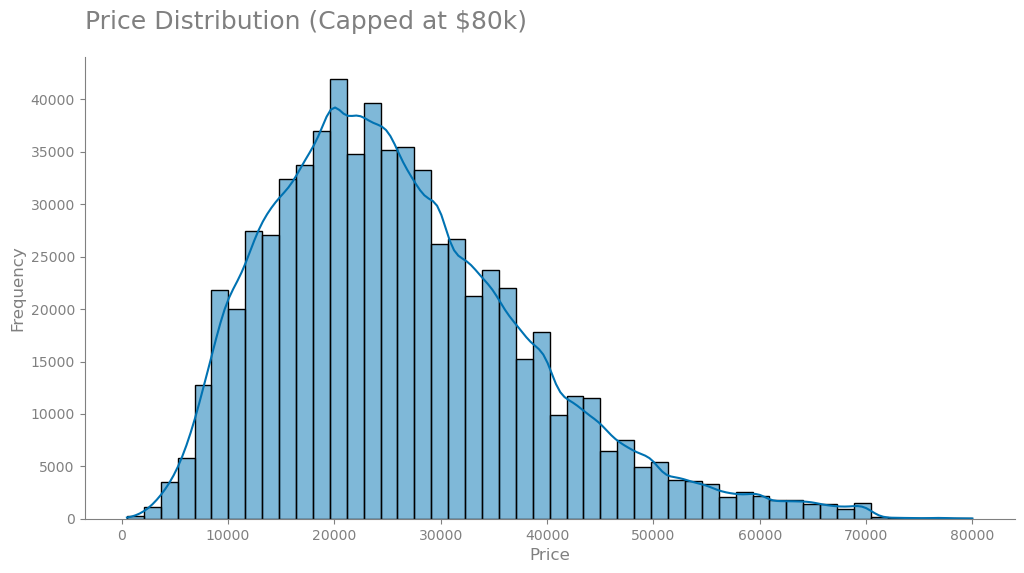

In [27]:
# Set figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Generate histogram and KDE for price capped at 80k to handle the long tail
sns.histplot(df[df['price'] < 80000]['price'], bins=50, kde=True, color=okabe_ito[4], ax=ax)

# Set the title for the price distribution plot aligned left with grey text
ax.set_title('Price Distribution (Capped at $80k)', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Price', color='grey', fontsize=12)
ax.set_ylabel('Frequency', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show price distribution plot
plt.show()

### Make (Manufacturing) Analysis

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/2811950042.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/2811950042.py:8: UserWarning: 
The palette list has fewer values (7) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


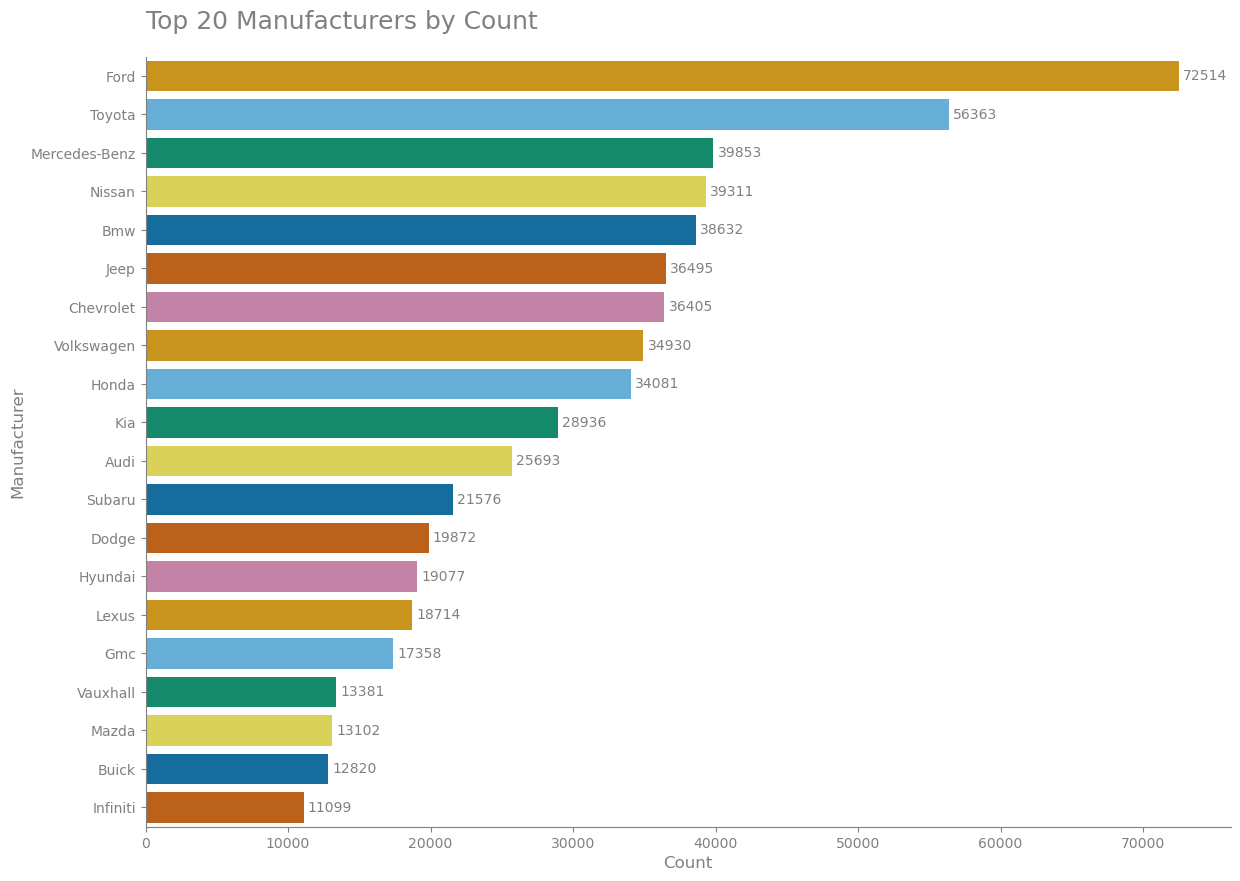

In [ ]:
# Set figure size for the manufacturer volume analysis
fig, ax = plt.subplots(figsize=(14, 10))

# Identify the top 20 manufacturers by vehicle volume
make_order = df['make'].value_counts().nlargest(20).index

# Generate horizontal count plot for the top 20 manufacturers
sns.countplot(
    data=df[df['make'].isin(make_order)], 
    y='make', 
    order=make_order, 
    ax=ax, 
    color=okabe_ito[4]
)

# Set the title for the manufacturer plot aligned left with grey text
ax.set_title('Top 20 Manufacturers by Count', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Count', color='grey', fontsize=12)
ax.set_ylabel('Manufacturer', color='grey', fontsize=12)

# Annotate bars with total vehicle counts per manufacturer using grey text
for container in ax.containers:
    ax.bar_label(container, padding=3, color='grey')

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show manufacturer distribution plot
plt.show()

### Fuel Type Distribution

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3293415084.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3293415084.py:8: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.countplot(


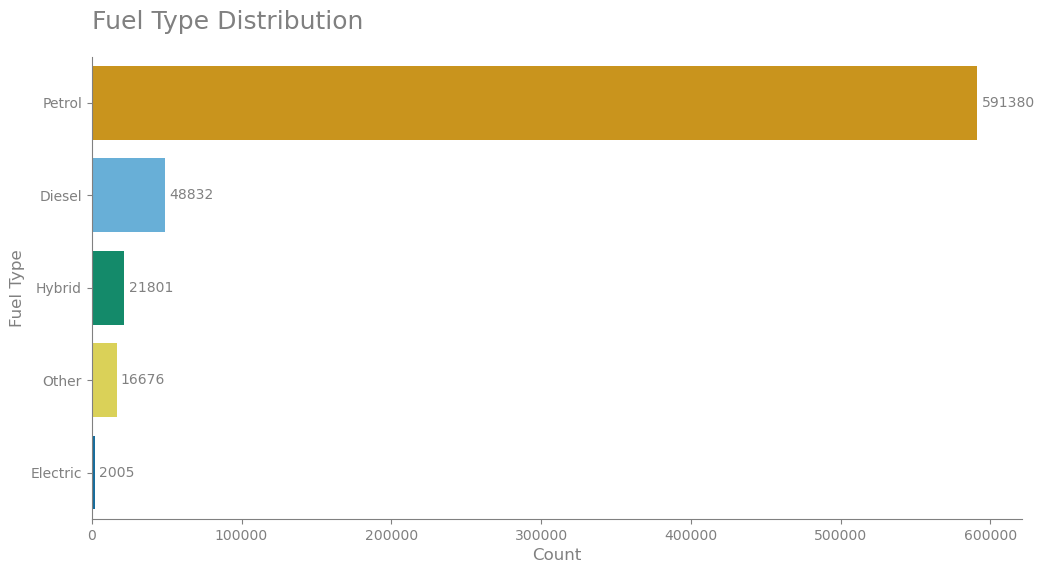

In [ ]:
# Set figure size for the fuel type analysis
fig, ax = plt.subplots(figsize=(12, 6))

# Identify the order of fuel types by frequency
fuel_order = df['fuelType'].value_counts().index

# Generate horizontal count plot for fuel types
sns.countplot(
    data=df, 
    y='fuelType', 
    order=fuel_order, 
    ax=ax, 
    color=okabe_ito[4]
)

# Set the title for the fuel type plot aligned left with grey text
ax.set_title('Fuel Type Distribution', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Count', color='grey', fontsize=12)
ax.set_ylabel('Fuel Type', color='grey', fontsize=12)

# Annotate bars with total counts for fuel types using grey text
for container in ax.containers:
    ax.bar_label(container, padding=3, color='grey')

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show fuel type distribution plot
plt.show()

### Milage Distribution

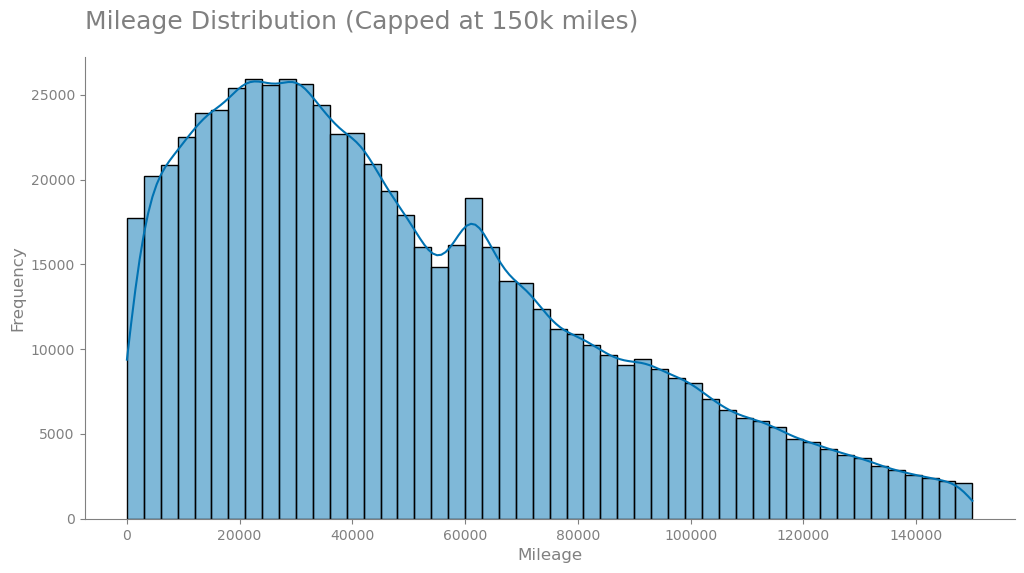

In [30]:
# Set figure size for the mileage distribution analysis
fig, ax = plt.subplots(figsize=(12, 6))

# Generate histogram and KDE for mileage capped at 150k to focus on the main market
sns.histplot(df[df['mileage'] < 150000]['mileage'], bins=50, kde=True, color=okabe_ito[4], ax=ax)

# Set the title for the mileage distribution plot aligned left with grey text
ax.set_title('Mileage Distribution (Capped at 150k miles)', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Mileage', color='grey', fontsize=12)
ax.set_ylabel('Frequency', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show mileage distribution plot
plt.show()

### Year/Age Frequency Analysis

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3565021705.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['year'].isin(recent_years)], x='year', palette=okabe_ito, ax=ax)
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3565021705.py:8: UserWarning: 
The palette list has fewer values (7) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df[df['year'].isin(recent_years)], x='year', palette=okabe_ito, ax=ax)


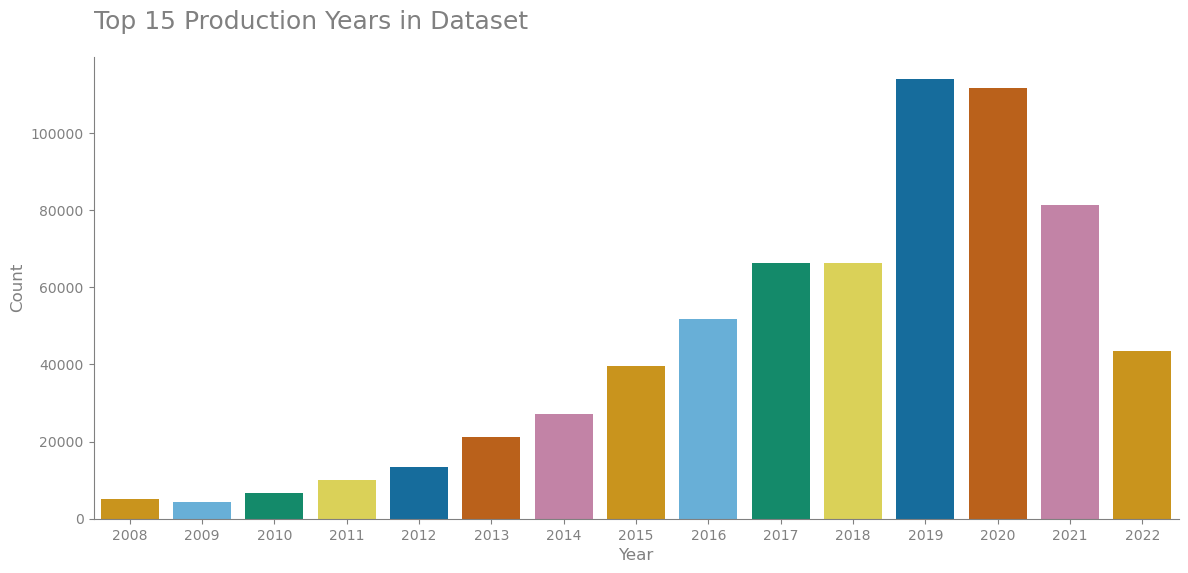

In [ ]:
# Set figure size for the year/age frequency analysis
fig, ax = plt.subplots(figsize=(14, 6))

# Identify the most common production years (last 15 years for clarity)
recent_years = df['year'].value_counts().nlargest(15).index.sort_values()

# Generate countplot for production years
sns.countplot(data=df[df['year'].isin(recent_years)], x='year', color=okabe_ito[4], ax=ax)

# Set the title for the year frequency plot aligned left with grey text
ax.set_title('Top 15 Production Years in Dataset', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Year', color='grey', fontsize=12)
ax.set_ylabel('Count', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show year frequency plot
plt.show()

### Transmission Prevalence Analysis

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/4121104097.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='transmission', order=trans_order, ax=ax, palette=okabe_ito)
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/4121104097.py:8: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.countplot(data=df, y='transmission', order=trans_order, ax=ax, palette=okabe_ito)


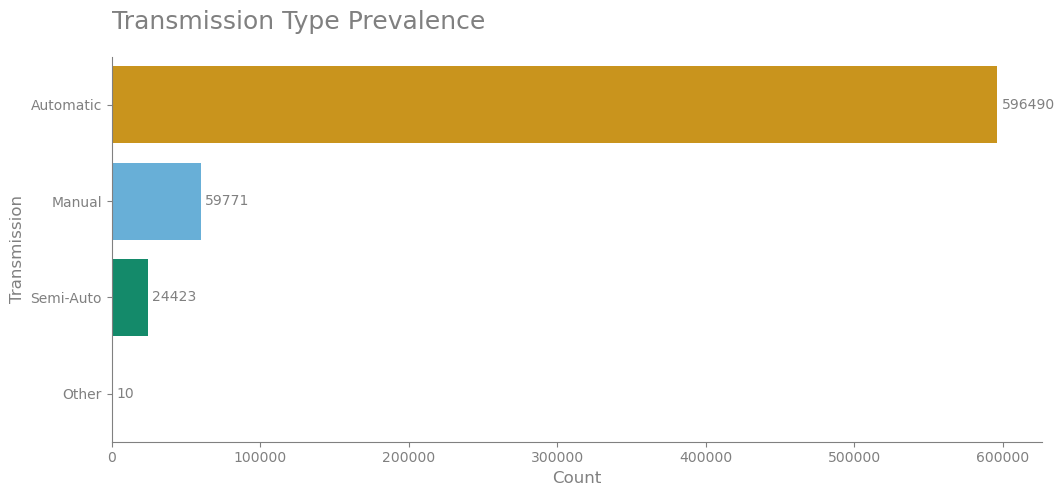

In [ ]:
# Set figure size for the transmission prevalence analysis
fig, ax = plt.subplots(figsize=(12, 5))

# Identify the order of transmission types by frequency
trans_order = df['transmission'].value_counts().index

# Generate horizontal count plot for transmission types
sns.countplot(data=df, y='transmission', order=trans_order, ax=ax, color=okabe_ito[4])

# Set the title for the transmission plot aligned left with grey text
ax.set_title('Transmission Type Prevalence', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Count', color='grey', fontsize=12)
ax.set_ylabel('Transmission', color='grey', fontsize=12)

# Annotate bars with total counts for transmissions using grey text
for container in ax.containers:
    ax.bar_label(container, padding=3, color='grey')

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show transmission plot
plt.show()

### Model Count Analysis

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3365391652.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3365391652.py:20: UserWarning: 
The palette list has fewer values (7) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


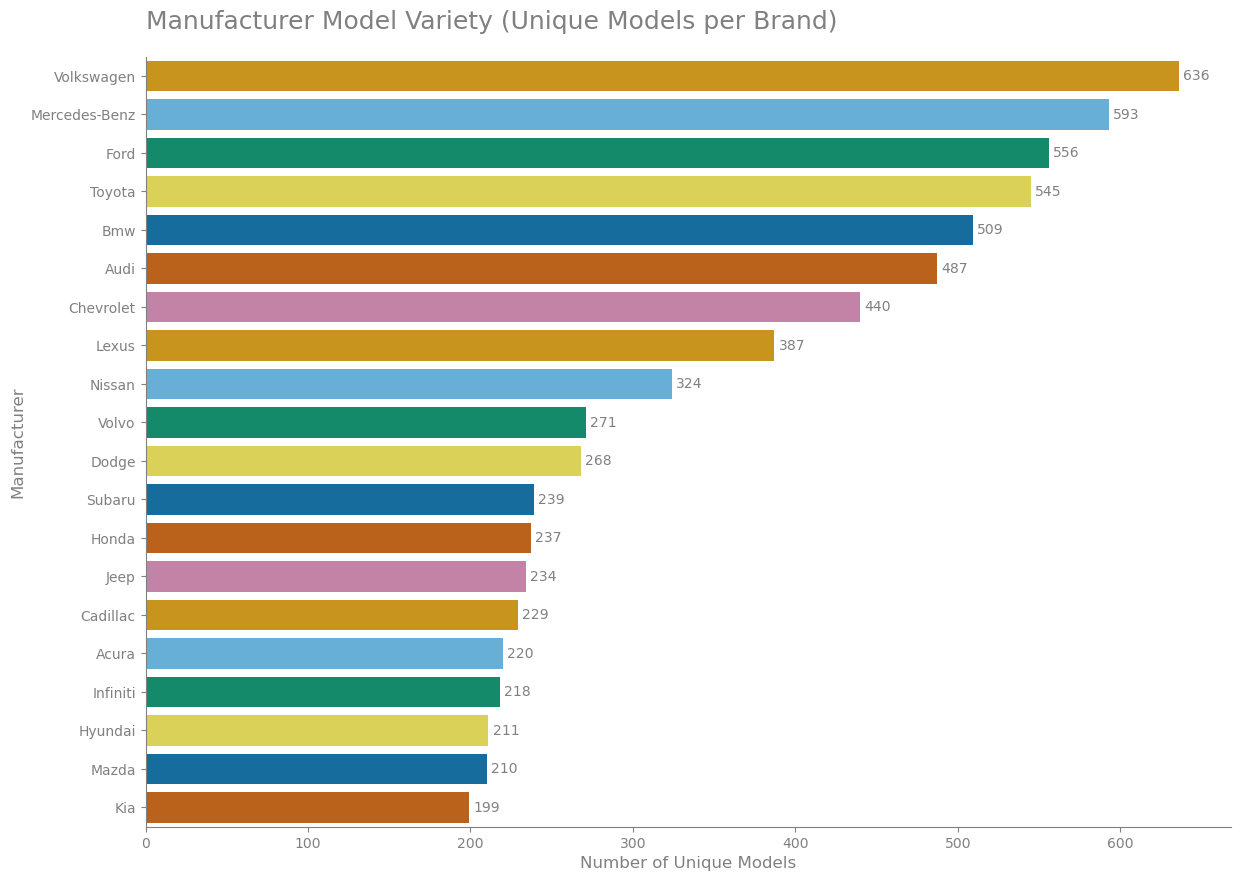

In [ ]:
# 1. Standardize casing to Title Case to merge "ford", "Ford", and "FORD"
df['make'] = df['make'].astype(str).str.strip().str.title()

# 2. Fix specific mapping errors visible in your graph (e.g., Cclass and Vw)
name_fixes = {
    'Cclass': 'Mercedes-Benz',
    'Merc': 'Mercedes-Benz',
    'Vw': 'Volkswagen',
    'Focus': 'Ford'
}
df['make'] = df['make'].replace(name_fixes)

# 3. Recalculate Variety and force a fresh Categorical index
model_variety = df.groupby('make', observed=True)['model'].nunique().sort_values(ascending=False).head(20)

# Set figure size
fig, ax = plt.subplots(figsize=(14, 10))

# 4. CRITICAL: The 'order' parameter forces Seaborn to ONLY show these 20 names
sns.barplot(
    x=model_variety.values, 
    y=model_variety.index, 
    order=model_variety.index, 
    ax=ax, 
    color=okabe_ito[4]
)

# Set the title and labels aligned left with grey text
ax.set_title('Manufacturer Model Variety (Unique Models per Brand)', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Number of Unique Models', color='grey', fontsize=12)
ax.set_ylabel('Manufacturer', color='grey', fontsize=12)

# Annotate bars with unique model counts
for container in ax.containers:
    ax.bar_label(container, padding=3, color='grey')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lighten remaining spines and ticks
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

plt.show()

### Price vs. Mileage Density Analysis

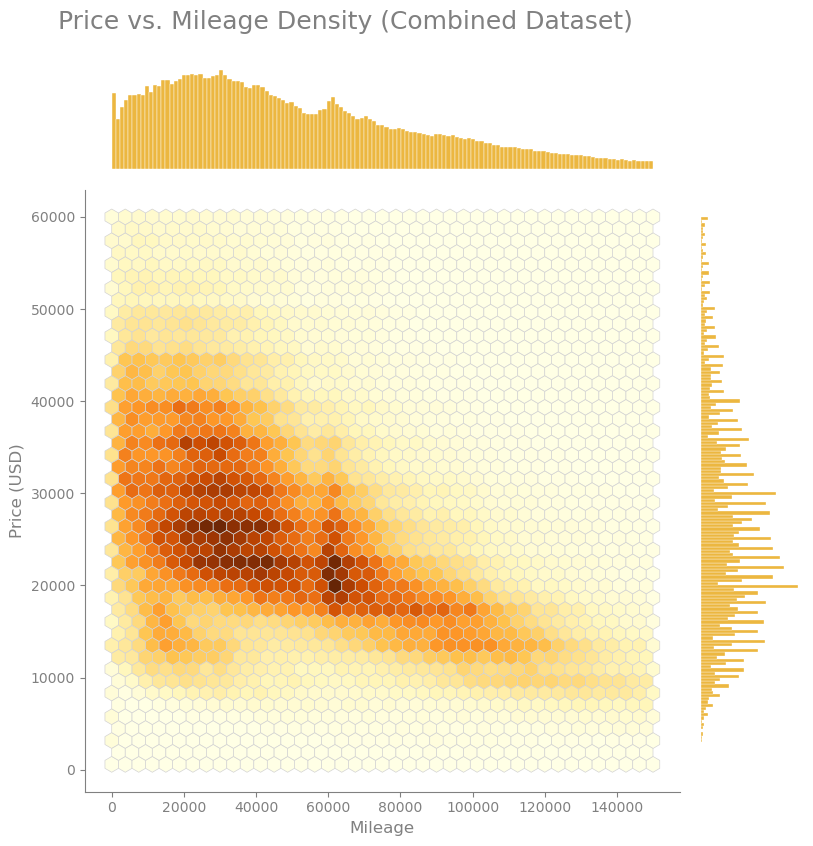

In [34]:
# Create a mask for outliers to focus the hexbin on the core market
rel_mask = (df['price'] < 60000) & (df['mileage'] < 150000)
df_rel = df[rel_mask]

# Generate hexbin plot using jointplot with marginal distributions
hb = sns.jointplot(
    data=df_rel, 
    x='mileage', 
    y='price', 
    kind='hex', 
    cmap='YlOrBr', 
    gridsize=40, 
    height=8,
    joint_kws={'edgecolors': 'lightgrey', 'linewidths': 0.5},
    marginal_kws={'color': okabe_ito[0], 'edgecolor': 'white'}
)

# Set axis labels and title aligned left with grey text
hb.ax_joint.set_xlabel('Mileage', color='grey', fontsize=12)
hb.ax_joint.set_ylabel('Price (USD)', color='grey', fontsize=12)
plt.suptitle("Price vs. Mileage Density (Combined Dataset)", 
             x=0.05, y=1.05, ha='left', fontsize=18, color='grey')

# Remove top and right spines
hb.ax_joint.spines['top'].set_visible(False)
hb.ax_joint.spines['right'].set_visible(False)
hb.ax_joint.spines['left'].set_color('grey')
hb.ax_joint.spines['bottom'].set_color('grey')
hb.ax_joint.tick_params(colors='grey')

# Clean marginal axes
for ax in [hb.ax_marg_x, hb.ax_marg_y]:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors='grey', length=0)

plt.show()

### Price Depreciation by Vehicle Age

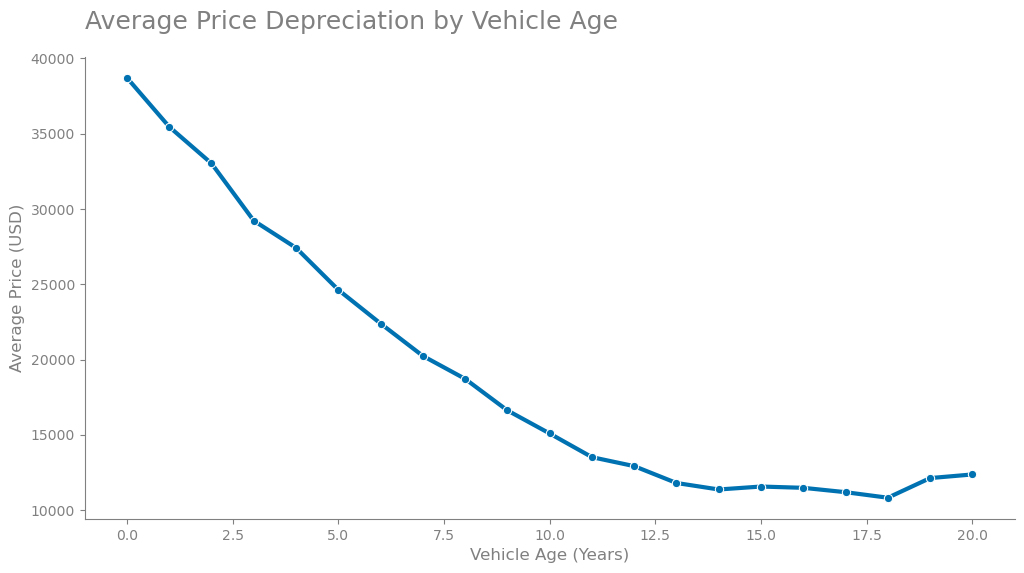

In [35]:
# Calculate average price per age to visualize the depreciation curve
age_depreciation = df.groupby('age')['price'].mean().reset_index()

# Set figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Generate line plot for price vs. age (capped at 20 years)
sns.lineplot(
    data=age_depreciation[age_depreciation['age'] <= 20], 
    x='age', 
    y='price', 
    marker='o', 
    color=okabe_ito[4], 
    linewidth=3,
    ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Average Price Depreciation by Vehicle Age', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Vehicle Age (Years)', color='grey', fontsize=12)
ax.set_ylabel('Average Price (USD)', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

plt.show()

### Efficiency Trade-off: MPG vs. Engine Size

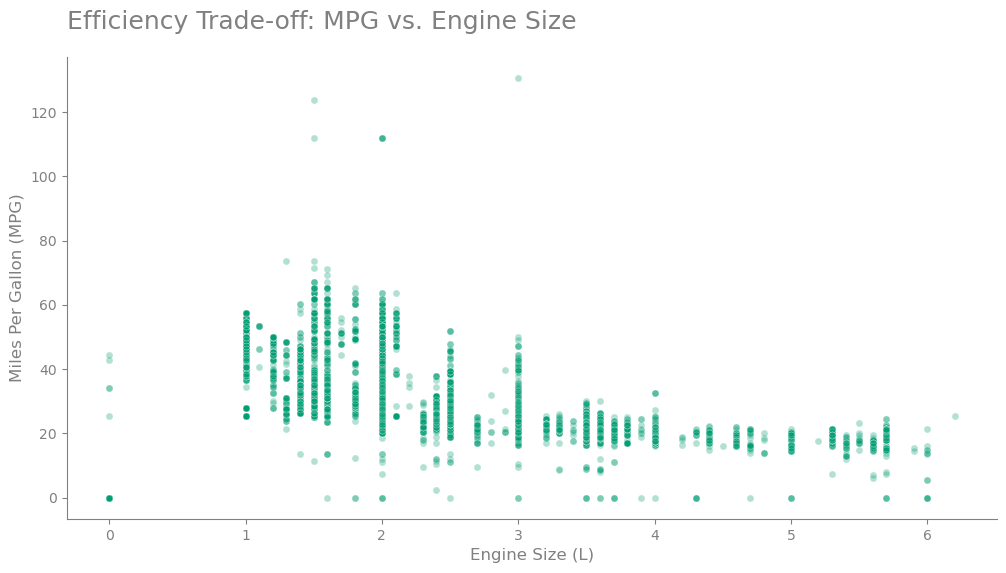

In [36]:
# Sample the data for scatter plots to prevent overplotting
df_sample = df.sample(min(10000, len(df)))

# Set figure size
fig, ax = plt.subplots(figsize=(12, 6))

# Generate scatter plot for MPG vs Engine Size
sns.scatterplot(
    data=df_sample, 
    x='engineSize', 
    y='mpg', 
    alpha=0.3, 
    s=25, 
    color=okabe_ito[2], 
    ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Efficiency Trade-off: MPG vs. Engine Size', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Engine Size (L)', color='grey', fontsize=12)
ax.set_ylabel('Miles Per Gallon (MPG)', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

plt.show()

### Price and Mileage Analysis by Fuel Type

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3429247029.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3429247029.py:8: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.boxplot(


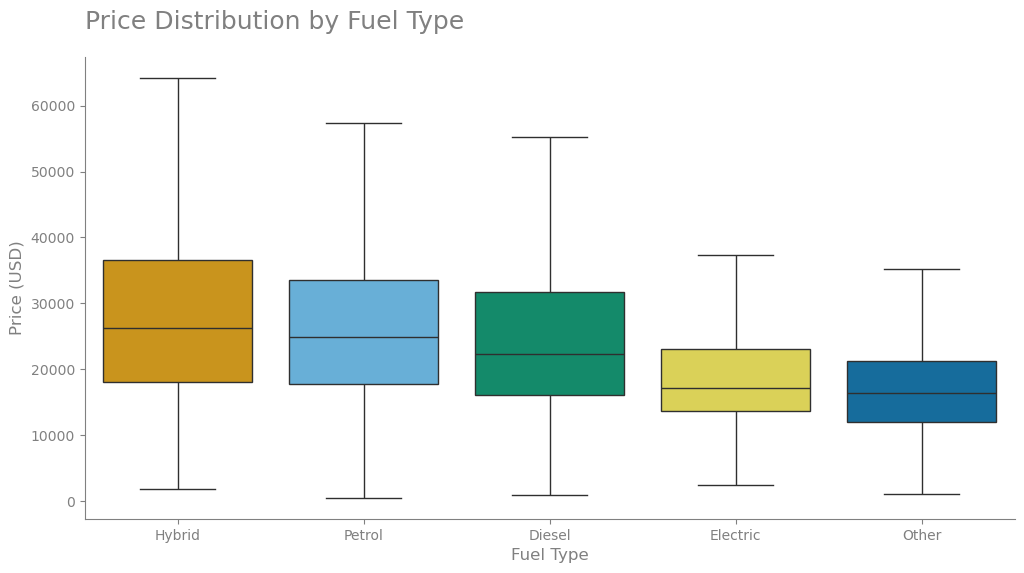

In [ ]:
# Set figure size for price by fuel type
fig, ax = plt.subplots(figsize=(12, 6))

# Order fuel types by median price
fuel_price_order = df.groupby('fuelType', observed=True)['price'].median().sort_values(ascending=False).index

# Generate boxplots for price by fuel type (hiding outliers)
sns.boxplot(
    data=df, x='fuelType', y='price', order=fuel_price_order,
    color=okabe_ito[4], showfliers=False, ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Price Distribution by Fuel Type', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Fuel Type', color='grey', fontsize=12)
ax.set_ylabel('Price (USD)', color='grey', fontsize=12)

# Standard visual cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

plt.show()

### Manufacturer Fuel Efficiency Ranking

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3015421327.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3015421327.py:9: UserWarning: 
The palette list has fewer values (7) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


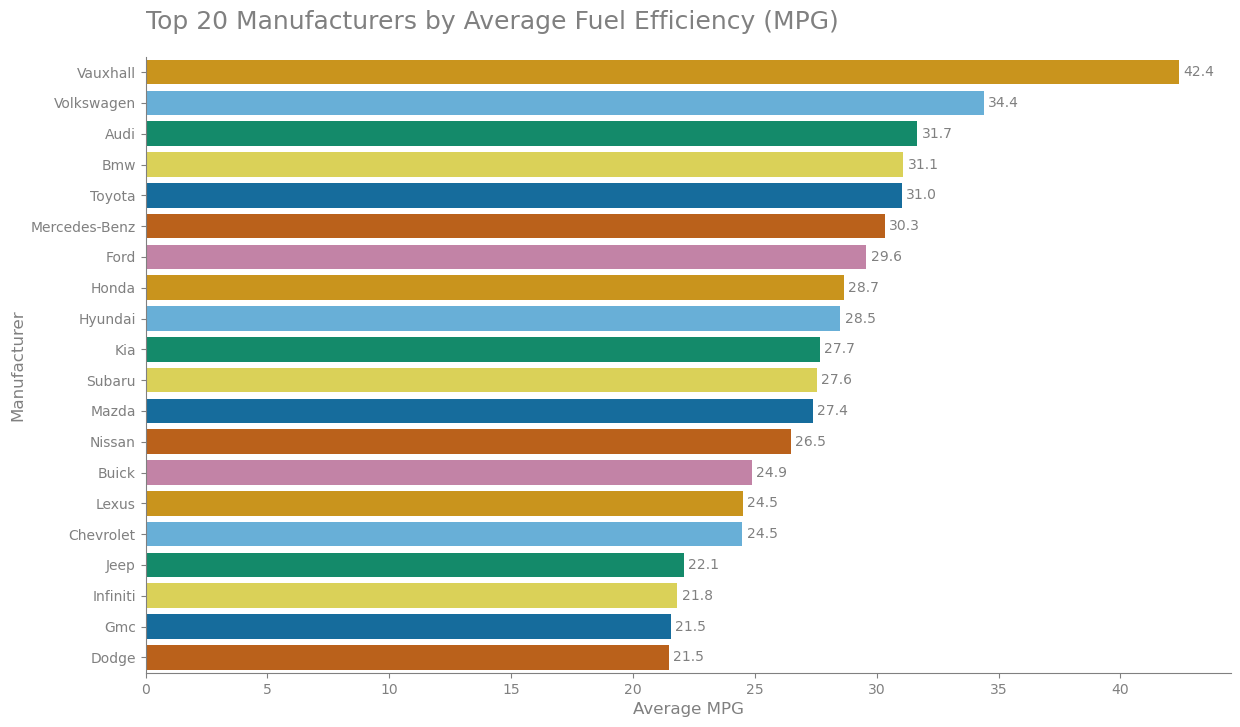

In [ ]:
# Set figure size
fig, ax = plt.subplots(figsize=(14, 8))

# Identify top 20 makes and calculate mean MPG
top_20_makes = df['make'].value_counts().nlargest(20).index
mpg_ranking = df[df['make'].isin(top_20_makes)].groupby('make', observed=True)['mpg'].mean().sort_values(ascending=False)

# Generate horizontal bar plot for efficiency ranking
sns.barplot(
    x=mpg_ranking.values, y=mpg_ranking.index, order=mpg_ranking.index,
    color=okabe_ito[4], ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Top 20 Manufacturers by Average Fuel Efficiency (MPG)', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Average MPG', color='grey', fontsize=12)
ax.set_ylabel('Manufacturer', color='grey', fontsize=12)

# Annotate bars with MPG values
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, color='grey')

# Visual cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

plt.show()

### Engine Size Distribution

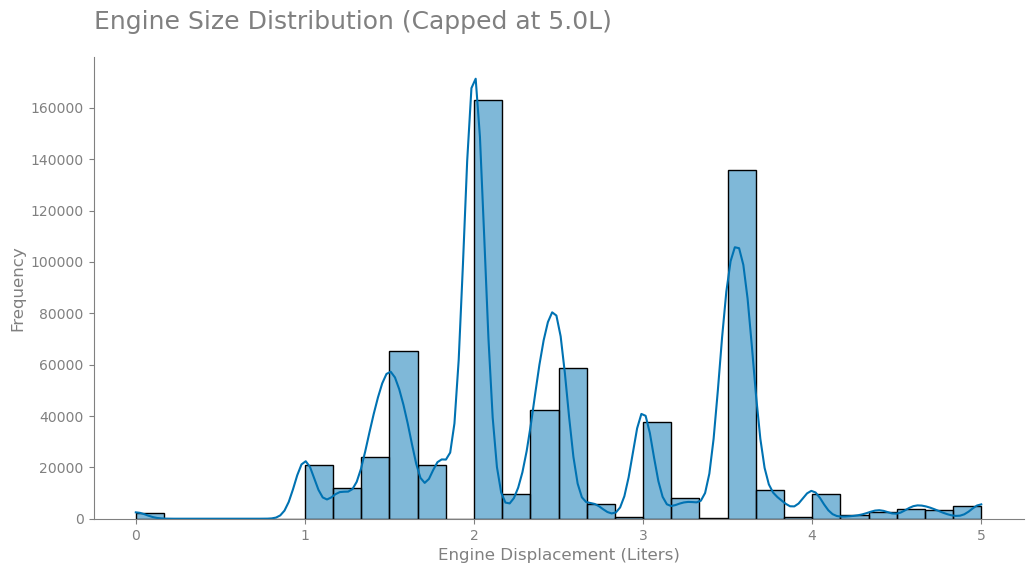

In [39]:
# Set figure size for engine size analysis
fig, ax = plt.subplots(figsize=(12, 6))

# Generate histogram for engine size capped at 5.0L to focus on consumer vehicles
sns.histplot(df[df['engineSize'] <= 5.0]['engineSize'], bins=30, kde=True, color=okabe_ito[4], ax=ax)

# Set the title for the engine size plot aligned left with grey text
ax.set_title('Engine Size Distribution (Capped at 5.0L)', loc='left', color='grey', fontsize=18, pad=20)

# Set axis labels with grey text
ax.set_xlabel('Engine Displacement (Liters)', color='grey', fontsize=12)
ax.set_ylabel('Frequency', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Use grey colour for the text and spines
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show engine size distribution
plt.show()

### Mileage vs. Age

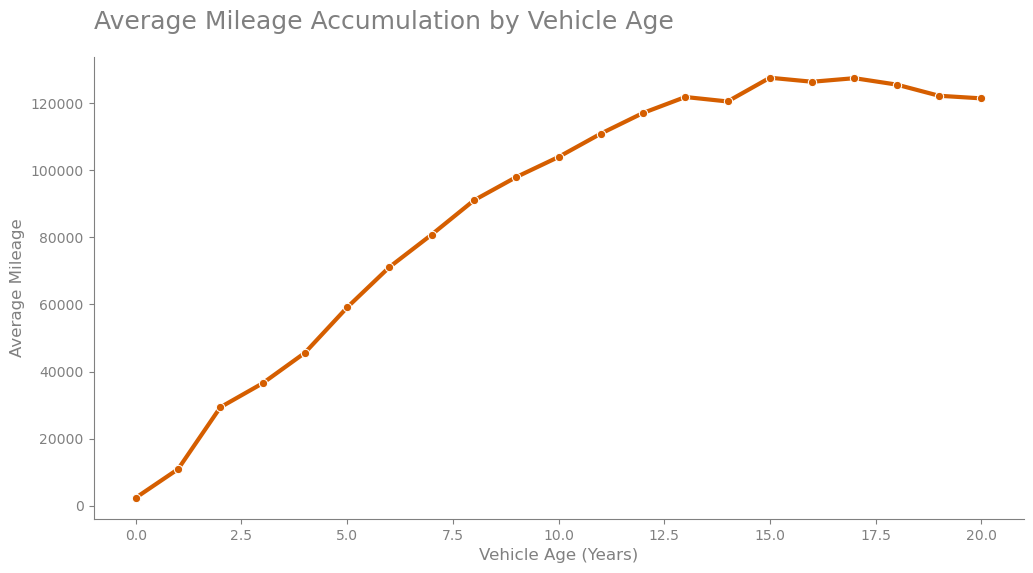

In [40]:
# Calculate average mileage per age to identify usage trends
mileage_age_trend = df.groupby('age')['mileage'].mean().reset_index()

# Set figure size for the mileage-age analysis
fig, ax = plt.subplots(figsize=(12, 6))

# Generate line plot showing mileage accumulation over time (capped at 20 years)
sns.lineplot(
    data=mileage_age_trend[mileage_age_trend['age'] <= 20], 
    x='age', 
    y='mileage', 
    marker='o', 
    color=okabe_ito[5], 
    linewidth=3,
    ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Average Mileage Accumulation by Vehicle Age', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Vehicle Age (Years)', color='grey', fontsize=12)
ax.set_ylabel('Average Mileage', color='grey', fontsize=12)

# Standard visual cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show mileage-age trend
plt.show()

### Price by Transmission

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3813378447.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/3813378447.py:8: UserWarning: The palette list has more values (7) than needed (4), which may not be intended.
  sns.boxplot(


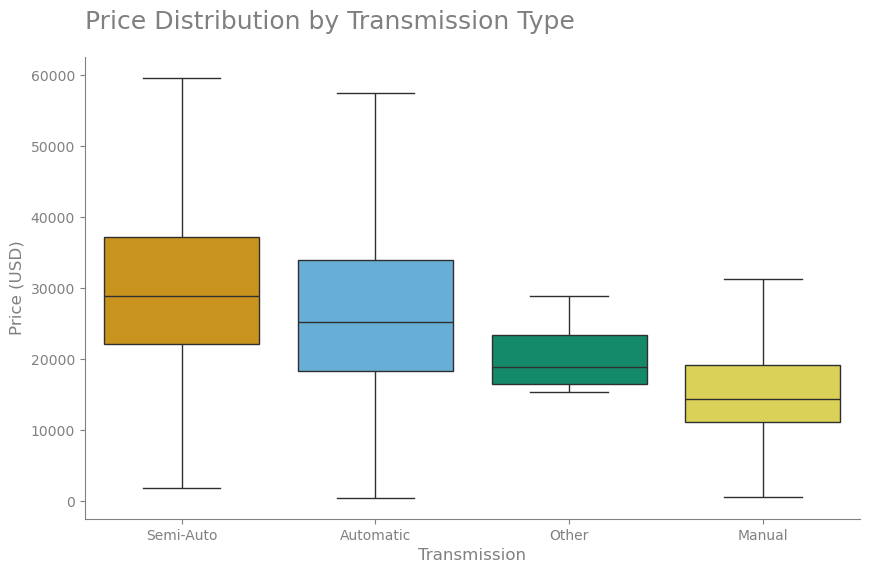

In [ ]:
# Set figure size for transmission price analysis
fig, ax = plt.subplots(figsize=(10, 6))

# Identify order by median price for the transmission types
trans_price_order = df.groupby('transmission', observed=True)['price'].median().sort_values(ascending=False).index

# Generate boxplots to compare valuation across gearboxes (hiding outliers)
sns.boxplot(
    data=df, 
    x='transmission', 
    y='price', 
    order=trans_price_order,
    color=okabe_ito[4], 
    showfliers=False,
    ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Price Distribution by Transmission Type', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Transmission', color='grey', fontsize=12)
ax.set_ylabel('Price (USD)', color='grey', fontsize=12)

# Remove top and right lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show transmission price boxplot
plt.show()

### Mileage by Fuel Type

/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/2875890797.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/y7/26jshzmn0g173gpd4sbpsk0m0000gp/T/ipykernel_56554/2875890797.py:8: UserWarning: The palette list has more values (7) than needed (5), which may not be intended.
  sns.boxplot(


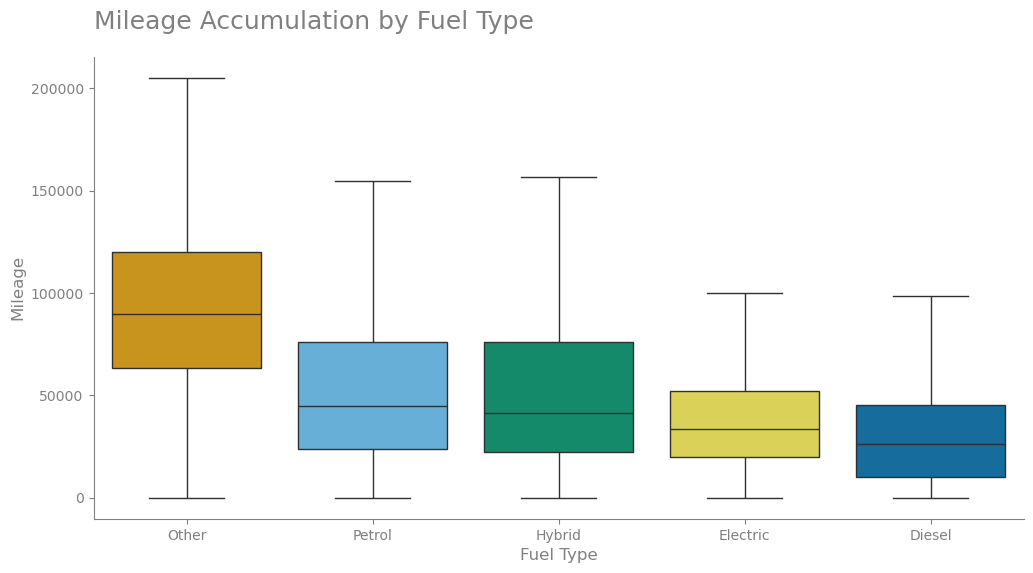

In [ ]:
# Set figure size for fuel type usage analysis
fig, ax = plt.subplots(figsize=(12, 6))

# Use the same order as previous fuel type charts for consistency
fuel_usage_order = df.groupby('fuelType', observed=True)['mileage'].median().sort_values(ascending=False).index

# Generate boxplots comparing mileage distributions across fuel types
sns.boxplot(
    data=df, 
    x='fuelType', 
    y='mileage', 
    order=fuel_usage_order,
    color=okabe_ito[4], 
    showfliers=False,
    ax=ax
)

# Set title and labels with grey formatting
ax.set_title('Mileage Accumulation by Fuel Type', loc='left', color='grey', fontsize=18, pad=20)
ax.set_xlabel('Fuel Type', color='grey', fontsize=12)
ax.set_ylabel('Mileage', color='grey', fontsize=12)

# Clean visual interface
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('grey')
ax.spines['bottom'].set_color('grey')
ax.tick_params(colors='grey')

# Show mileage fuel boxplot
plt.show()

## Multivariate

### 

### Numerical Feature Correlation Matrix

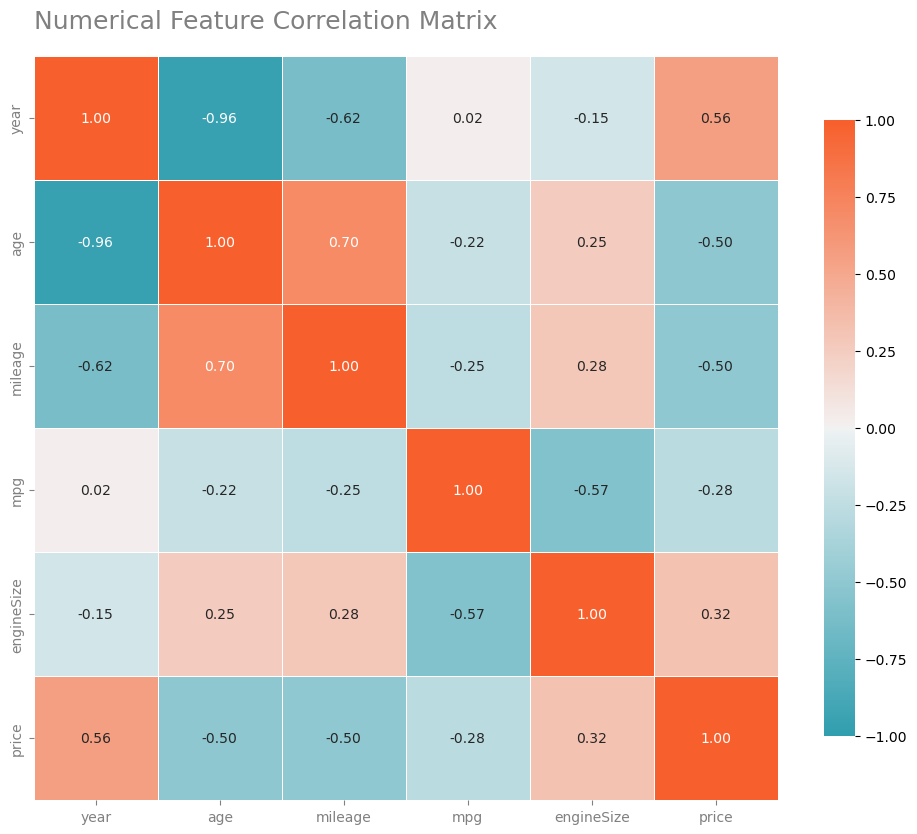

In [43]:
# Filter for numerical columns and calculate correlation
num_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[num_cols].corr()

# Set figure size
fig, ax = plt.subplots(figsize=(12, 10))

# Use vibrant colorblind-friendly diverging palette
vibrant_cb_palette = sns.diverging_palette(h_neg=210, h_pos=20, s=90, l=60, as_cmap=True)

# Generate heatmap
sns.heatmap(
    corr_matrix, annot=True, cmap=vibrant_cb_palette, fmt=".2f", 
    vmin=-1, vmax=1, square=True, linewidths=.5, cbar_kws={"shrink": .8}, ax=ax
)

# Set title with grey formatting
ax.set_title('Numerical Feature Correlation Matrix', loc='left', color='grey', fontsize=18, pad=20)
ax.tick_params(colors='grey')

plt.show()